# 03 — Data Cleaning & Preprocessing (Part 1)

**Objective:** Clean the clinical trials dataset by handling missing values structurally, removing duplicates, fixing inconsistencies, and mitigating outliers through Winsorization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load dataset
df = pd.read_csv('../data/dataset.csv')
print(f"Original shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Original shape: 12,272 rows × 17 columns


---
## 1. Missing Values

In [3]:
# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Count': missing,
    'Percentage (%)': (missing / len(df) * 100).round(2)
})
display(missing_df)

,Count,Percentage (%)
phase,5971,48.66
has_dmc,2027,16.52
enrollment_count,403,3.28


### Missing Values Strategy

| Variable | Strategy | Justification |
| :--- | :--- | :--- |
| `phase` | Fill with `"NA"` | The absence of a phase is informative in clinical trials (e.g., behavioral interventions). |
| `has_dmc` | Fill with mode (`0`) | DMC is often absent or unreported; 0 is the most common baseline state. |
| `enrollment_count` | Fill with median | Median is robust to the heavily right-skewed distribution of enrollment sizes. |

*Note: We will apply the `phase` filling immediately as it is a structural missingness. Imputations for `has_dmc` and `enrollment_count` will be handled later within a formal modeling pipeline.*

In [4]:
# Implement phase filling
df['phase'] = df['phase'].fillna('NA')
print(f"Missing values in 'phase' after filling: {df['phase'].isnull().sum()}")

Missing values in 'phase' after filling: 0


---
## 2. Duplicates & Inconsistencies

In [5]:
# Detect and drop exact duplicates
duplicates = df.duplicated().sum()
print(f"Exact duplicate rows detected: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Shape after dropping duplicates: {df.shape[0]:,} rows")

Exact duplicate rows detected: 39
Shape after dropping duplicates: 12,233 rows


In [6]:
# Check inconsistencies
print("Inconsistency Checks:")
print("-" * 30)

invalid_enrollment = df[df['enrollment_count'] < 0]
print(f"Trials with enrollment_count < 0: {len(invalid_enrollment)}")

invalid_arms = df[df['n_arms'] < 0]
print(f"Trials with n_arms < 0: {len(invalid_arms)}")

invalid_locations = df[df['n_locations'] < 0]
print(f"Trials with n_locations < 0: {len(invalid_locations)}")

# Check: is_multicenter == 1 implies n_locations > 1
multicenter_violations = df[(df['is_multicenter'] == 1) & (df['n_locations'] <= 1)]
print(f"Trials marked as multicenter but n_locations <= 1: {len(multicenter_violations)}")

Inconsistency Checks:
------------------------------
Trials with enrollment_count < 0: 0
Trials with n_arms < 0: 0
Trials with n_locations < 0: 0
Trials marked as multicenter but n_locations <= 1: 0


In [7]:
# Fix inconsistencies

# 1. Drop rows where enrollment_count < 0 (invalid trial data)
if len(invalid_enrollment) > 0:
    df = df.drop(invalid_enrollment.index)

# 2. For multicenter violations, we'll correct is_multicenter to 0 since n_locations is more factual
if len(multicenter_violations) > 0:
    # Note: recompute the boolean mask after potential drops
    violation_idx = df[(df['is_multicenter'] == 1) & (df['n_locations'] <= 1)].index
    df.loc[violation_idx, 'is_multicenter'] = 0

print(f"Shape after fixing inconsistencies: {df.shape[0]:,} rows")

abandoned_ratio = df['abandoned'].mean()
print(f"Abandoned ratio after cleaning: {abandoned_ratio:.1%}")

Shape after fixing inconsistencies: 12,233 rows
Abandoned ratio after cleaning: 13.7%


---
## 3. Outliers

In [8]:
# Numerical variables for outlier detection
NUMERICAL_COLS = [
    'enrollment_count', 'n_arms', 'n_primary_outcomes',
    'n_secondary_outcomes', 'outcomes_ratio', 'n_locations', 'n_collaborators'
]

# Compute IQR bounds and summarize
outlier_summary = []

for col in NUMERICAL_COLS:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (n_outliers / df[col].notna().sum()) * 100
    
    outlier_summary.append({
        'Variable': col,
        'n_outliers': n_outliers,
        '% outliers': round(pct_outliers, 2),
        'lower_bound': round(lower_bound, 2),
        'upper_bound': round(upper_bound, 2)
    })

outliers_df = pd.DataFrame(outlier_summary)
display(outliers_df)

,Variable,n_outliers,% outliers,lower_bound,upper_bound
0,enrollment_count,1414,11.95,-151.00,329.00
1,n_arms,1396,11.41,0.50,4.50
2,n_primary_outcomes,1451,11.86,-0.50,3.50
3,n_secondary_outcomes,1005,8.22,-5.00,11.00
4,outcomes_ratio,907,7.41,-4.75,9.25
5,n_locations,2182,17.84,-0.50,3.50
6,n_collaborators,539,4.41,-1.50,2.50


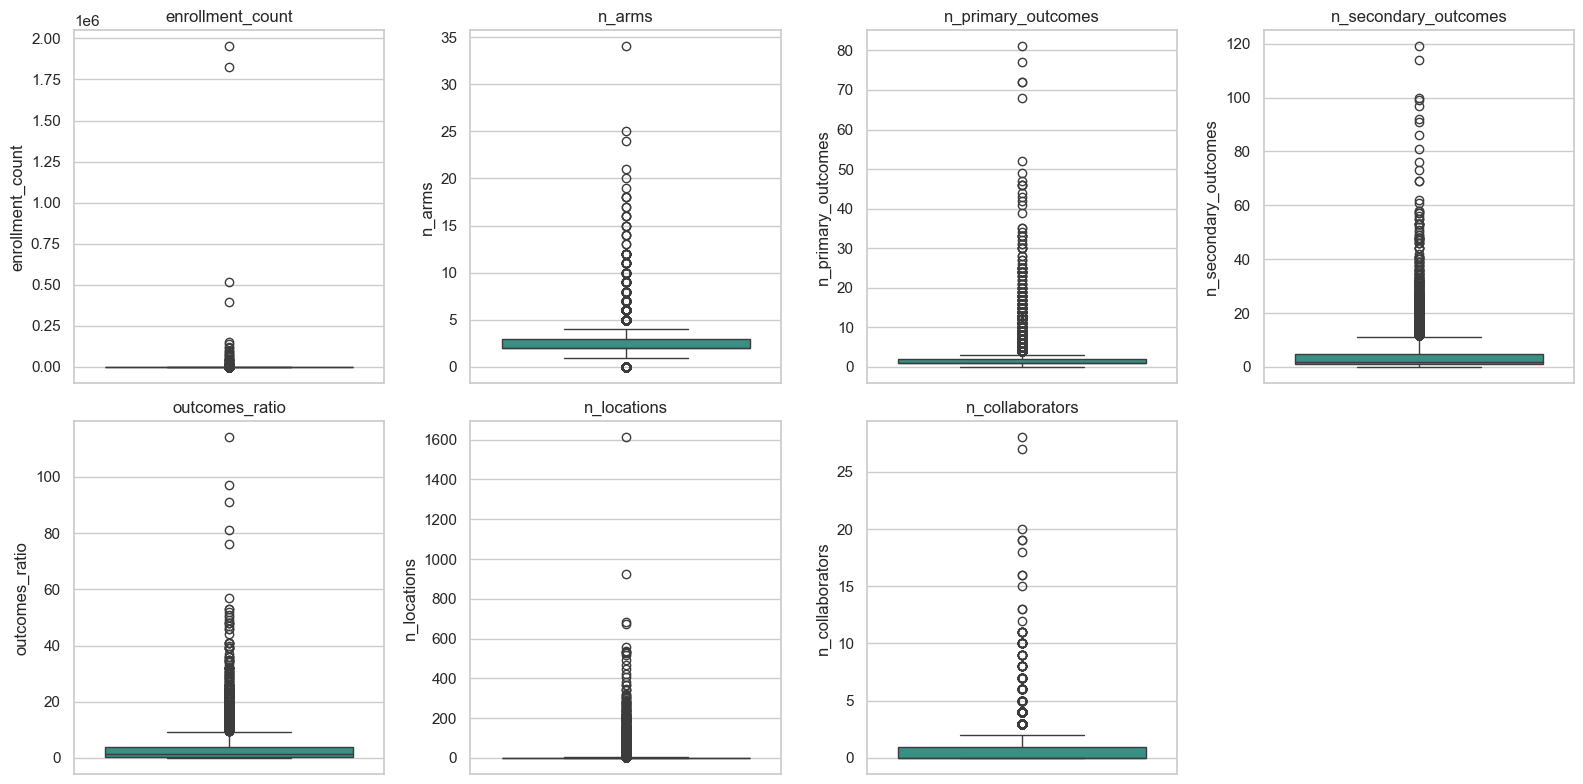

In [9]:
# Plot boxplots for all numerical variables in a grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='#2a9d8f')
    axes[i].set_title(col)

# Hide the 8th empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Outlier Strategy: Winsorization
**Decision: KEEP all outliers.** Clinical trials inherently exhibit massive variance (e.g., extremely large multinational Phase 3 trials). However, to prevent extreme values from distorting models down the line, we will apply **Winsorization at the 1st and 99th percentiles**. This caps the extreme tails without entirely deleting valid rows.

In [10]:
# Implement Winsorization (using pandas .clip based on percentiles)
for col in NUMERICAL_COLS:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

print("✓ Winsorization applied to all numerical columns at 1st and 99th percentiles.")

✓ Winsorization applied to all numerical columns at 1st and 99th percentiles.


---
## 4. Final Output

In [11]:
# Final shape report
print(f"Final Cleaned DataFrame Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Final Cleaned DataFrame Shape: 12,233 rows × 17 columns


## Summary of Decisions Made

1. **Missing Values**: Handled the structurally informative missing `phase` by assigning it the string `"NA"`. Imputations for `has_dmc` and `enrollment_count` are documented but deferred to the modeling pipeline.
2. **Duplicates**: Detected and dropped exact duplicate rows to prevent data leakage and bias.
3. **Inconsistencies**:
   - Dropped rows where `enrollment_count < 0` (true errors). Kept rows where `enrollment_count == 0` because they represent valid WITHDRAWN trials.
   - Fixed `is_multicenter` flag violations by resetting them to `0` when `n_locations <= 1`.
4. **Outliers**: Identified significant outliers across most numerical columns due to trial scale variability. Kept all rows but mitigated the effect of extreme tails using **1st-99th percentile Winsorization** via `.clip()`.

---
## 5. Feature Engineering

In this section, we create new features designed to capture non-linear relationships, clinical trial complexity, and structural operational risks.

### 5.1 Log Enrollment
**Justification:** `enrollment_count` is heavily right-skewed. A logarithmic transformation (`log1p` to handle zeros safely) normalizes the distribution, pulling in long tails and making it easier for linear models or tree models to capture its relationship with the target.

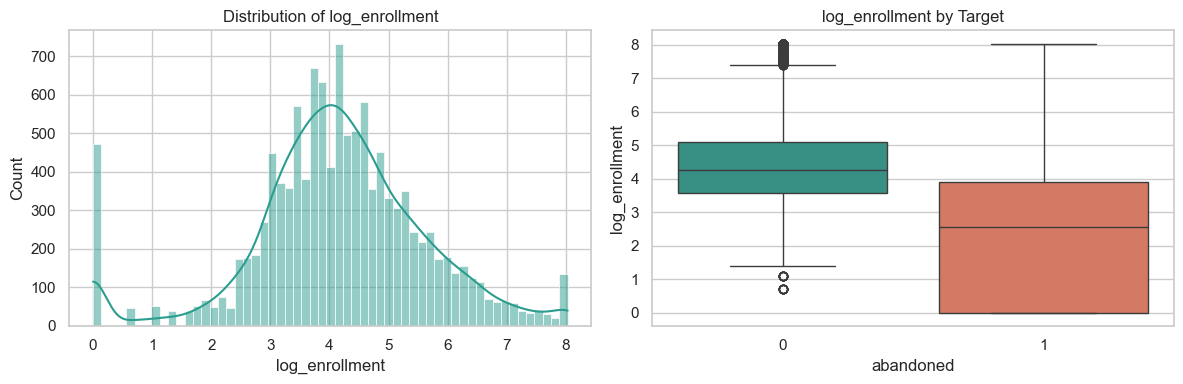

Correlation with target (abandoned): -0.4536


In [12]:
# Create log_enrollment
df['log_enrollment'] = np.log1p(df['enrollment_count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['log_enrollment'].dropna(), kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of log_enrollment')

sns.boxplot(data=df, x='abandoned', y='log_enrollment', hue='abandoned', ax=axes[1], palette=['#2a9d8f', '#e76f51'], legend=False)
axes[1].set_title('log_enrollment by Target')
plt.tight_layout()
plt.show()

corr = df['log_enrollment'].corr(df['abandoned'])
print(f"Correlation with target (abandoned): {corr:.4f}")

### 5.2 Log Locations
**Justification:** `n_locations` is similarly heavily right-skewed. Transforming it with `log1p` stabilizes variance and normalizes the feature space, allowing models to treat differences at the lower end (e.g., 1 vs 5 sites) as relatively larger than differences at the higher end (e.g., 100 vs 105 sites).

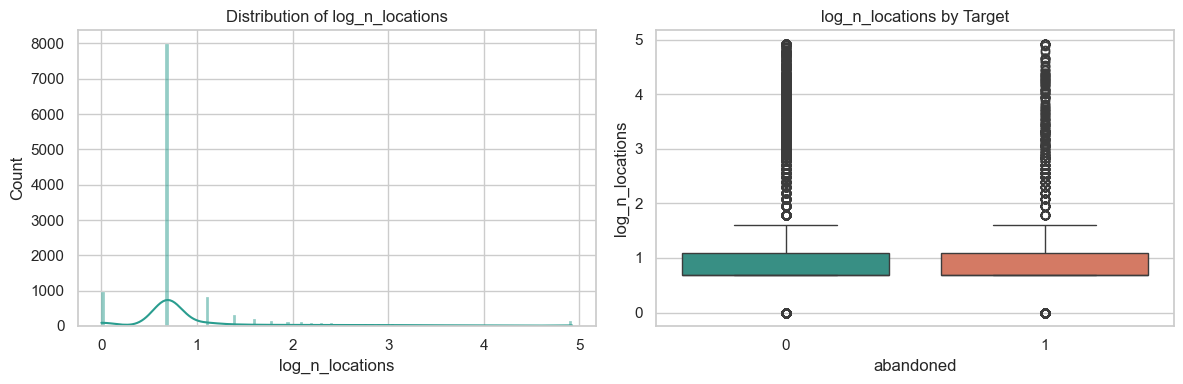

Correlation with target (abandoned): 0.0161


In [13]:
# Create log_n_locations
df['log_n_locations'] = np.log1p(df['n_locations'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['log_n_locations'].dropna(), kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of log_n_locations')

sns.boxplot(data=df, x='abandoned', y='log_n_locations', hue='abandoned', ax=axes[1], palette=['#2a9d8f', '#e76f51'], legend=False)
axes[1].set_title('log_n_locations by Target')
plt.tight_layout()
plt.show()

corr = df['log_n_locations'].corr(df['abandoned'])
print(f"Correlation with target (abandoned): {corr:.4f}")

### 5.3 Protocol Complexity
**Justification:** `protocol_complexity` is an interaction feature (`n_arms * n_primary_outcomes`). From a clinical trial business perspective, trials with many arms AND many primary outcomes are structurally more complex, requiring more data collection, longer timelines, and higher administrative burden. This makes them inherently harder to complete, increasing the dropout/abandonment risk.

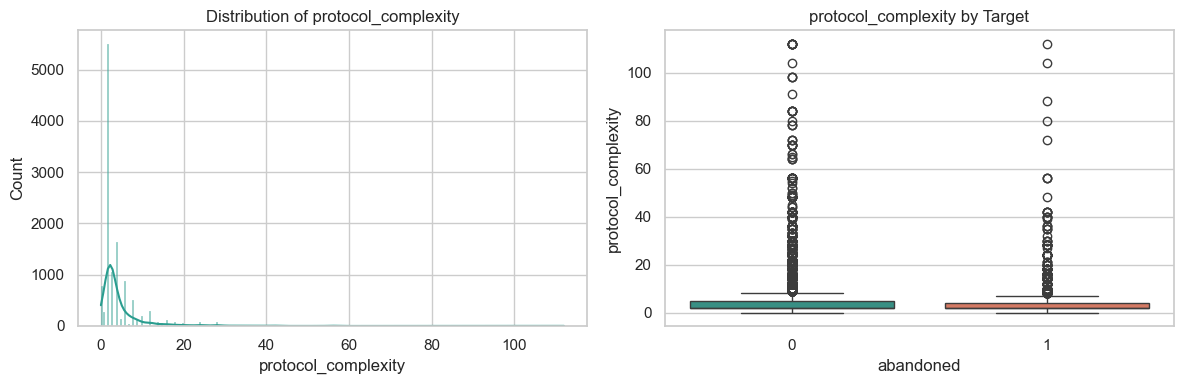

Correlation with target (abandoned): -0.0157


In [14]:
# Create protocol_complexity
df['protocol_complexity'] = df['n_arms'] * df['n_primary_outcomes']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['protocol_complexity'].dropna(), kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of protocol_complexity')

sns.boxplot(data=df, x='abandoned', y='protocol_complexity', hue='abandoned', ax=axes[1], palette=['#2a9d8f', '#e76f51'], legend=False)
axes[1].set_title('protocol_complexity by Target')
plt.tight_layout()
plt.show()

corr = df['protocol_complexity'].corr(df['abandoned'])
print(f"Correlation with target (abandoned): {corr:.4f}")

### 5.4 Enrollment Per Site
**Justification:** `enrollment_per_site` (`enrollment_count / (n_locations + 1)`) measures the recruitment pressure per site. A high ratio means each site must recruit a large number of patients. This translates to higher operational risk, as failing sites can heavily jeopardize the trial, potentially leading to higher abandonment risk. The `+1` is added to the denominator to prevent division by zero for trials lacking location data.

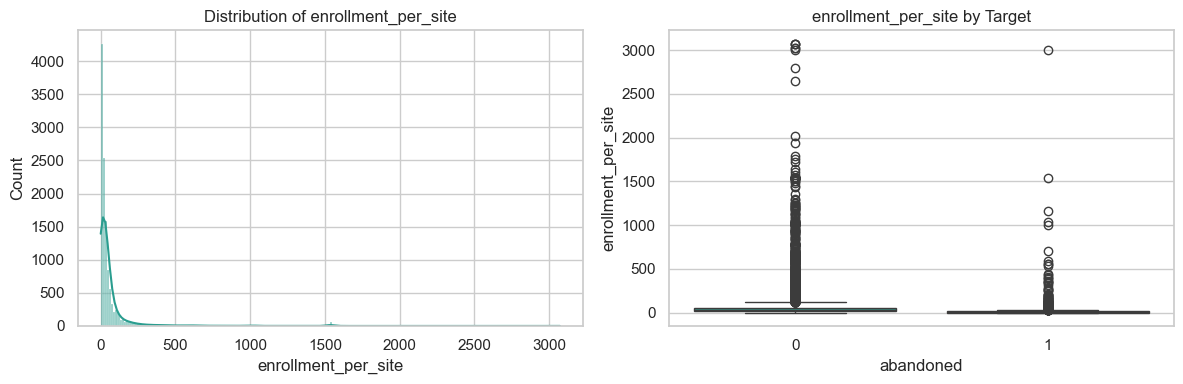

Correlation with target (abandoned): -0.0975


In [15]:
# Create enrollment_per_site
df['enrollment_per_site'] = df['enrollment_count'] / (df['n_locations'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['enrollment_per_site'].dropna(), kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of enrollment_per_site')

sns.boxplot(data=df, x='abandoned', y='enrollment_per_site', hue='abandoned', ax=axes[1], palette=['#2a9d8f', '#e76f51'], legend=False)
axes[1].set_title('enrollment_per_site by Target')
plt.tight_layout()
plt.show()

corr = df['enrollment_per_site'].corr(df['abandoned'])
print(f"Correlation with target (abandoned): {corr:.4f}")

In [16]:
# Confirm new columns
print(f"Final shape after Feature Engineering: {df.shape}")
df.head(3)

Final shape after Feature Engineering: (12233, 21)


,phase,sponsor_type,enrollment_count,intervention_type,n_arms,has_dmc,allocation,masking,primary_purpose,n_primary_outcomes,...,outcomes_ratio,n_locations,is_multicenter,has_us_site,n_collaborators,abandoned,log_enrollment,log_n_locations,protocol_complexity,enrollment_per_site
0,PHASE3,NETWORK,120.0,DRUG,2,1.0,RANDOMIZED,QUADRUPLE,TREATMENT,1,...,12.000000,1.0,0,0,0,0,4.795791,0.693147,2,60.000000
1,PHASE4,OTHER,80.0,DRUG,4,0.0,RANDOMIZED,TRIPLE,TREATMENT,3,...,1.666667,2.0,1,0,0,0,4.394449,1.098612,12,26.666667
2,NA,OTHER,121.0,BEHAVIORAL,2,1.0,RANDOMIZED,SINGLE,TREATMENT,1,...,3.000000,2.0,1,1,0,0,4.804021,1.098612,2,40.333333


---
## 6. Train / Validation / Test Split
To prevent data leakage, we split the dataset into Train (70%), Validation (15%), and Test (15%) subsets *before* fitting any imputation or scaling pipelines. We stratify by the target variable (`abandoned`) to preserve the severe class imbalance across all splits.

In [17]:
from sklearn.model_selection import train_test_split

TARGET = 'abandoned'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split 70% Train, 30% Temp (which will be split 50-50 into Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Split Temp into 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print("-" * 40)
print("Class Distribution Verification:")
print(f"Train:      {y_train.value_counts(normalize=True).to_dict()}")
print(f"Validation: {y_val.value_counts(normalize=True).to_dict()}")
print(f"Test:       {y_test.value_counts(normalize=True).to_dict()}")

X_train shape: (8563, 20)
X_val shape:   (1835, 20)
X_test shape:  (1835, 20)
----------------------------------------
Class Distribution Verification:
Train:      {0: 0.8633656428821674, 1: 0.13663435711783253}
Validation: {0: 0.8637602179836512, 1: 0.1362397820163488}
Test:       {0: 0.8632152588555858, 1: 0.13678474114441416}


---
## 7. Preprocessing Pipeline
We build a modular `ColumnTransformer` with `Pipeline` components for different feature types:
- **Numerical:** Impute with median → Scale with `RobustScaler` (resistant to our remaining outliers)
- **Categorical:** Impute with mode → `OneHotEncoder` (dropping the first category to avoid multicollinearity)
- **Binary:** Passthrough

*Crucially, the pipeline is fit **only** on `X_train` to prevent data leakage.*

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Define feature groups
NUM_COLS = [
    'enrollment_count', 'n_arms', 'n_primary_outcomes', 'n_secondary_outcomes', 'outcomes_ratio',
    'n_locations', 'n_collaborators', 'log_enrollment', 'log_n_locations',
    'protocol_complexity', 'enrollment_per_site'
]
CAT_COLS = ['phase', 'sponsor_type', 'intervention_type', 'allocation', 'masking', 'primary_purpose']
BIN_COLS = ['has_dmc', 'is_multicenter', 'has_us_site']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, NUM_COLS),
        ('cat', cat_pipe, CAT_COLS),
        ('bin', SimpleImputer(strategy='most_frequent'), BIN_COLS)
    ],
    remainder='drop'  # Drop anything not explicitly specified
)

# Fit exclusively on training data
preprocessor.fit(X_train)

# Transform all sets
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_val shape:   {X_val_processed.shape}")
print(f"Processed X_test shape:  {X_test_processed.shape}")

Processed X_train shape: (8563, 53)
Processed X_val shape:   (1835, 53)
Processed X_test shape:  (1835, 53)


---
## 8. Save Processed Datasets
We recover the feature names dynamically from the `OneHotEncoder` and save the transformed DataFrames (including the target) so modeling notebooks can load them cleanly without re-running the pipeline.

In [19]:
import os

# Extract feature names for categorical columns
try:
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CAT_COLS)
except AttributeError:
    # Fallback for older scikit-learn
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names(CAT_COLS)

# Combine all feature names
feature_names = NUM_COLS + list(cat_feature_names) + BIN_COLS

# Convert numpy arrays back to Pandas DataFrames
df_train_proc = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
df_train_proc[TARGET] = y_train

df_val_proc = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
df_val_proc[TARGET] = y_val

df_test_proc = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
df_test_proc[TARGET] = y_test

# Save
os.makedirs('../data/processed', exist_ok=True)
df_train_proc.to_csv('../data/processed/train.csv', index=False)
df_val_proc.to_csv('../data/processed/validation.csv', index=False)
df_test_proc.to_csv('../data/processed/test.csv', index=False)

print("✓ Saved transformed datasets to data/processed/")

✓ Saved transformed datasets to data/processed/


---
## 9. Serialize Pipeline
We save the fitted preprocessor so that future raw data can be processed consistently in production or inference scripts.

In [20]:
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print("✓ Saved fitted pipeline to models/preprocessor.joblib")

# Anti-leakage verification: reload and apply to 1 sample from X_test
loaded_preprocessor = joblib.load('../models/preprocessor.joblib')
sample = X_test.iloc[[0]]
sample_processed = loaded_preprocessor.transform(sample)

print(f"Reload verification success. Sample output shape: {sample_processed.shape}")

✓ Saved fitted pipeline to models/preprocessor.joblib
Reload verification success. Sample output shape: (1, 53)


---
## 10. Imbalance Mitigation Strategies
Before entering the modeling phase, we prepare several resampling strategies using `imbalanced-learn` to combat the ~86%/14% class imbalance. *Note: Resampling is strictly applied only to the training set.*

In [21]:
# Note: Ensure imbalanced-learn is installed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

strategy_1 = "No resampling — use class_weight='balanced' in the model"
strategy_2 = SMOTE(random_state=42)
strategy_3 = RandomUnderSampler(random_state=42)
strategy_4 = SMOTETomek(random_state=42)

print("Original Training Class Distribution:")
print(f"  {Counter(y_train)}\n")

print("Strategy 1: " + strategy_1 + "\n")

print("Strategy 2: SMOTE")
X_res2, y_res2 = strategy_2.fit_resample(X_train_processed, y_train)
print(f"  {Counter(y_res2)}\n")

print("Strategy 3: RandomUnderSampler")
X_res3, y_res3 = strategy_3.fit_resample(X_train_processed, y_train)
print(f"  {Counter(y_res3)}\n")

print("Strategy 4: SMOTETomek (Bonus)")
X_res4, y_res4 = strategy_4.fit_resample(X_train_processed, y_train)
print(f"  {Counter(y_res4)}")

Original Training Class Distribution:
  Counter({0: 7393, 1: 1170})

Strategy 1: No resampling — use class_weight='balanced' in the model

Strategy 2: SMOTE
  Counter({0: 7393, 1: 7393})

Strategy 3: RandomUnderSampler
  Counter({0: 1170, 1: 1170})

Strategy 4: SMOTETomek (Bonus)
  Counter({0: 7363, 1: 7363})


---
## Summary of Pipeline Decisions
- **Data Splitting**: We split into 70/15/15 before applying any statistics-based operations to strictly avoid data leakage. Stratified splits guarantee identical imbalance profiles across train, val, and test.
- **Missing Values**: Applied `median` imputation to continuous features and `most_frequent` to categoricals via Scikit-Learn's `SimpleImputer`.
- **Scaling & Encoding**: Used `RobustScaler` on continuous features because it scales effectively around outliers (which we kept via Winsorization). Used `OneHotEncoder` on categoricals, dropping the first category to sidestep multicollinearity for linear models.
- **Persistence**: Saved our transformed clean datasets as `.csv` and serialized the fitted pipeline as `.joblib` for future inference workflows.
- **Class Imbalance Preparations**: We have defined and previewed `SMOTE`, `RandomUnderSampler`, and `SMOTETomek` as strategies to resolve the clinical trial abandonment imbalance in Phase 3.